In [18]:
# GitHub Commands
# git pull (to get the latest code)

# git add Project3/FinalProject.ipynb
# git commit -m "text"
# git push

# The Problem & Dataset

We’re investigating the effects primarily online classes have had on student success since before remote learning was prominent in schools. We’re specifically looking for whether graduation outcomes overall have increased or decreased as online classes have become a more prominent method of instruction.

We seek to investigate the relationship between prominent online schooling and student performance in college, if one exists.

This problem matters because it gives us a better understanding of how distance learning can support or hurt students and the rise of distance learning after COVID-19. The results from this project can be used to identify whether or not distance learning is beneficial for students and what institutions are using distance learning most effectively.

We are using a dataset derived from IPEDS Data Center with features related to our problem. Our dataset accounts for public four-year institutions across multiple years. The dataset include data to identify institutions, instidution demographics, and data about the presence of fully remote learning options. 

The dataset includes the following features:

- unitid - unique institutional ID number
- institution_name - name of the college or university
- year - year the data was recorded
- avg_net_price - average net price of attendance for students
- grad_rate_150pct_4yr - 4-year institution graduation rate measured at 150% of normal completion time
- hispanic_count - number of Hispanic students enrolled
- black_count - number of Black students enrolled
- white_count - number of White students enrolled
- hispanic_share - proportion of enrolled students who are Hispanic
- black_share - proportion of enrolled students who are Black
- white_share - proportion of enrolled students who are White
- distance_only_share - proportion of students enrolled exclusively in distance education
- distance_only_count - number of students enrolled exclusively in distance education
- distance_only_share_imputed - imputed proportion of students enrolled exclusively in distance education
- distance_data_available - indicator for whether distance education data is available
- control_of_institution - control type of the institution
- level_of_institution - institution level
- sector_of_institution - institutional sector classification

Variable Notes
- grad_rate_150pct_4yr: Because this is measured at 150% of normal completion time. This means completion within about 6 years, not 4 years.
- avg_net_price: Represents average net cost after financial aid
- In general variables related to distance education only county students who are fully remote learners. Students who take a mix of in-person and remote classes are not represented in these columns.

# Data Preprocessing & Assumptions

In [20]:
# Import Packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

### Load Data

In [21]:
# Load the data
df = pd.read_csv("education_data.csv")

### Understanding the Dataset

In [22]:
df.head()

,unitid,institution_name,year,avg_net_price,grad_rate_150pct_4yr,hispanic_count,black_count,white_count,hispanic_share,black_share,white_share,distance_only_count,distance_only_share_imputed,distance_data_available,control_of_institution,level_of_institution,sector_of_institution
0,100654,Alabama A & M University,2017,15812,0.239571,51,5361,232,0.008499,0.893351,0.038660,121,NaN,NaN,Public,Four or more years,"Public, 4-year or above"
1,100654,Alabama A & M University,2020,15373,0.286573,62,5140,111,0.010373,0.859963,0.018571,1869,0.312699,NaN,Public,Four or more years,"Public, 4-year or above"
2,100654,Alabama A & M University,2023,14064,0.287383,88,5664,128,0.013305,0.856365,0.019353,406,0.061385,1.0,Public,Four or more years,"Public, 4-year or above"
3,100663,University of Alabama at Birmingham,2017,17016,0.529188,673,4435,12530,0.032198,0.212181,0.599464,4917,NaN,NaN,Public,Four or more years,"Public, 4-year or above"
4,100663,University of Alabama at Birmingham,2020,16978,0.612019,1050,4746,12966,0.046536,0.210344,0.574658,6346,0.281257,NaN,Public,Four or more years,"Public, 4-year or above"


In [23]:
df.describe()

,unitid,year,avg_net_price,grad_rate_150pct_4yr,hispanic_count,black_count,white_count,hispanic_share,black_share,white_share,distance_only_count,distance_only_share_imputed,distance_data_available
count,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1150.000000,593.0
mean,192983.009924,2020.052539,13961.921191,0.512358,2148.614711,1371.000584,6891.969060,0.132371,0.137457,0.550965,3035.262113,0.283051,1.0
std,67934.900445,2.464618,4318.328944,0.176012,3924.011600,1806.542353,7155.016284,0.145954,0.193450,0.238125,5851.533719,0.254512,0.0
min,100654.000000,2017.000000,306.000000,0.029412,1.000000,0.000000,4.000000,0.000193,0.000000,0.006421,0.000000,0.000000,1.0
25%,155681.000000,2017.000000,11256.000000,0.387368,221.000000,199.000000,1645.000000,0.044495,0.035056,0.424387,407.000000,0.097285,1.0
50%,187985.000000,2020.000000,13958.000000,0.508547,686.000000,746.000000,4414.000000,0.077318,0.069881,0.609518,1146.000000,0.205723,1.0
75%,216764.000000,2023.000000,16736.000000,0.630305,2206.000000,1824.000000,9444.000000,0.157435,0.143514,0.740911,3014.000000,0.378310,1.0
max,498571.000000,2023.000000,29785.000000,1.000000,38139.000000,17417.000000,39653.000000,0.956732,0.950933,0.923513,53815.000000,1.000000,1.0


In [24]:
df.shape

(1713, 17)

In [25]:
df.dtypes

unitid                           int64
institution_name                object
year                             int64
avg_net_price                    int64
grad_rate_150pct_4yr           float64
hispanic_count                   int64
black_count                      int64
white_count                      int64
hispanic_share                 float64
black_share                    float64
white_share                    float64
distance_only_count              int64
distance_only_share_imputed    float64
distance_data_available        float64
control_of_institution          object
level_of_institution            object
sector_of_institution           object
dtype: object

In [26]:
# Veiw the number of each value in each column
for col in df.columns:
    print(f"{col}:\n {df[col].value_counts()}\n")

unitid:
 unitid
100654    3
204024    3
203483    3
203492    3
203517    3
         ..
235167    1
114433    1
118912    1
141839    1
498571    1
Name: count, Length: 597, dtype: int64

institution_name:
 institution_name
Lincoln University                          5
Miami University-Oxford                     3
Kent State University at Tuscarawas         3
Kent State University at Salem              3
Kent State University at Kent               3
                                           ..
The Evergreen State College                 1
Feather River Community College District    1
MiraCosta College                           1
The University of Tennessee Southern        1
Pennsylvania Western University             1
Name: count, Length: 596, dtype: int64

year:
 year
2023    593
2017    563
2020    557
Name: count, dtype: int64

avg_net_price:
 avg_net_price
13381    3
10151    3
14706    2
14216    2
18480    2
        ..
17231    1
10991    1
22954    1
22505    1
19579    1
Name

### Data Cleaning

In [27]:
# Delete duplcate rows
df = df.drop_duplicates()
print("Duplicate rows: " + str(df.duplicated().sum()))

Duplicate rows: 0


In [28]:
# Drop columns that are consistent across all institutions. All institutions are public, 4 year institutions
df = df.drop(columns=["control_of_institution", "level_of_institution", "sector_of_institution"])

In [29]:
# Check for null values
df.isnull().sum()

unitid                            0
institution_name                  0
year                              0
avg_net_price                     0
grad_rate_150pct_4yr              0
hispanic_count                    0
black_count                       0
white_count                       0
hispanic_share                    0
black_share                       0
white_share                       0
distance_only_count               0
distance_only_share_imputed     563
distance_data_available        1120
dtype: int64

In [30]:
# Drop distance_data_available because it is not useful and is not correctly filled out. It is liely that this was a variable added after 2020 and that is why it is only present in 2023.
df = df.drop(columns=["distance_data_available"])

In [31]:
# Using race share and count to calculate total enrollment
df["total_enrollment"] = ((df["white_count"] + df["black_count"] + df["hispanic_count"]) / (df["white_share"] + df["black_share"] + df["hispanic_share"])).round().astype(int)

In [32]:
# Fill in missing distance share values using distance count and total enrollment
df["distance_only_share_imputed"] = df["distance_only_share_imputed"].fillna(df["distance_only_count"] / df["total_enrollment"])

In [33]:
# Drop count columns since we have the share columns and total enrollment
df = df.drop(columns=["white_count", "black_count", "hispanic_count", "distance_only_count"])

In [34]:
# Ensure preprocessing steps were successful
df.head()

,unitid,institution_name,year,avg_net_price,grad_rate_150pct_4yr,hispanic_share,black_share,white_share,distance_only_share_imputed,total_enrollment
0,100654,Alabama A & M University,2017,15812,0.239571,0.008499,0.893351,0.038660,0.020163,6001
1,100654,Alabama A & M University,2020,15373,0.286573,0.010373,0.859963,0.018571,0.312699,5977
2,100654,Alabama A & M University,2023,14064,0.287383,0.013305,0.856365,0.019353,0.061385,6614
3,100663,University of Alabama at Birmingham,2017,17016,0.529188,0.032198,0.212181,0.599464,0.235241,20902
4,100663,University of Alabama at Birmingham,2020,16978,0.612019,0.046536,0.210344,0.574658,0.281257,22563


### Exploratory Data Analysis

<Axes: xlabel='grad_rate_150pct_4yr', ylabel='Count'>

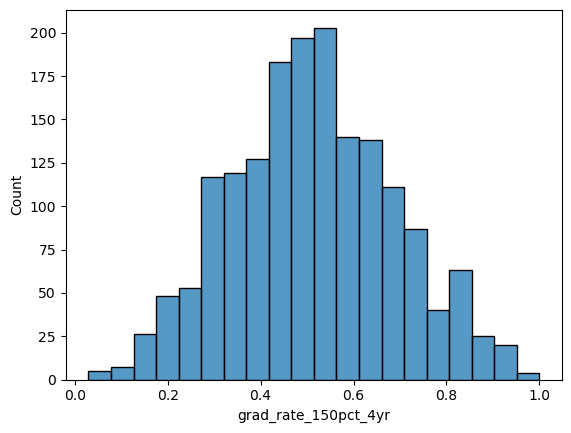

In [38]:
# Visualize the distribution of the target variable
sns.histplot(df["grad_rate_150pct_4yr"], bins=20)

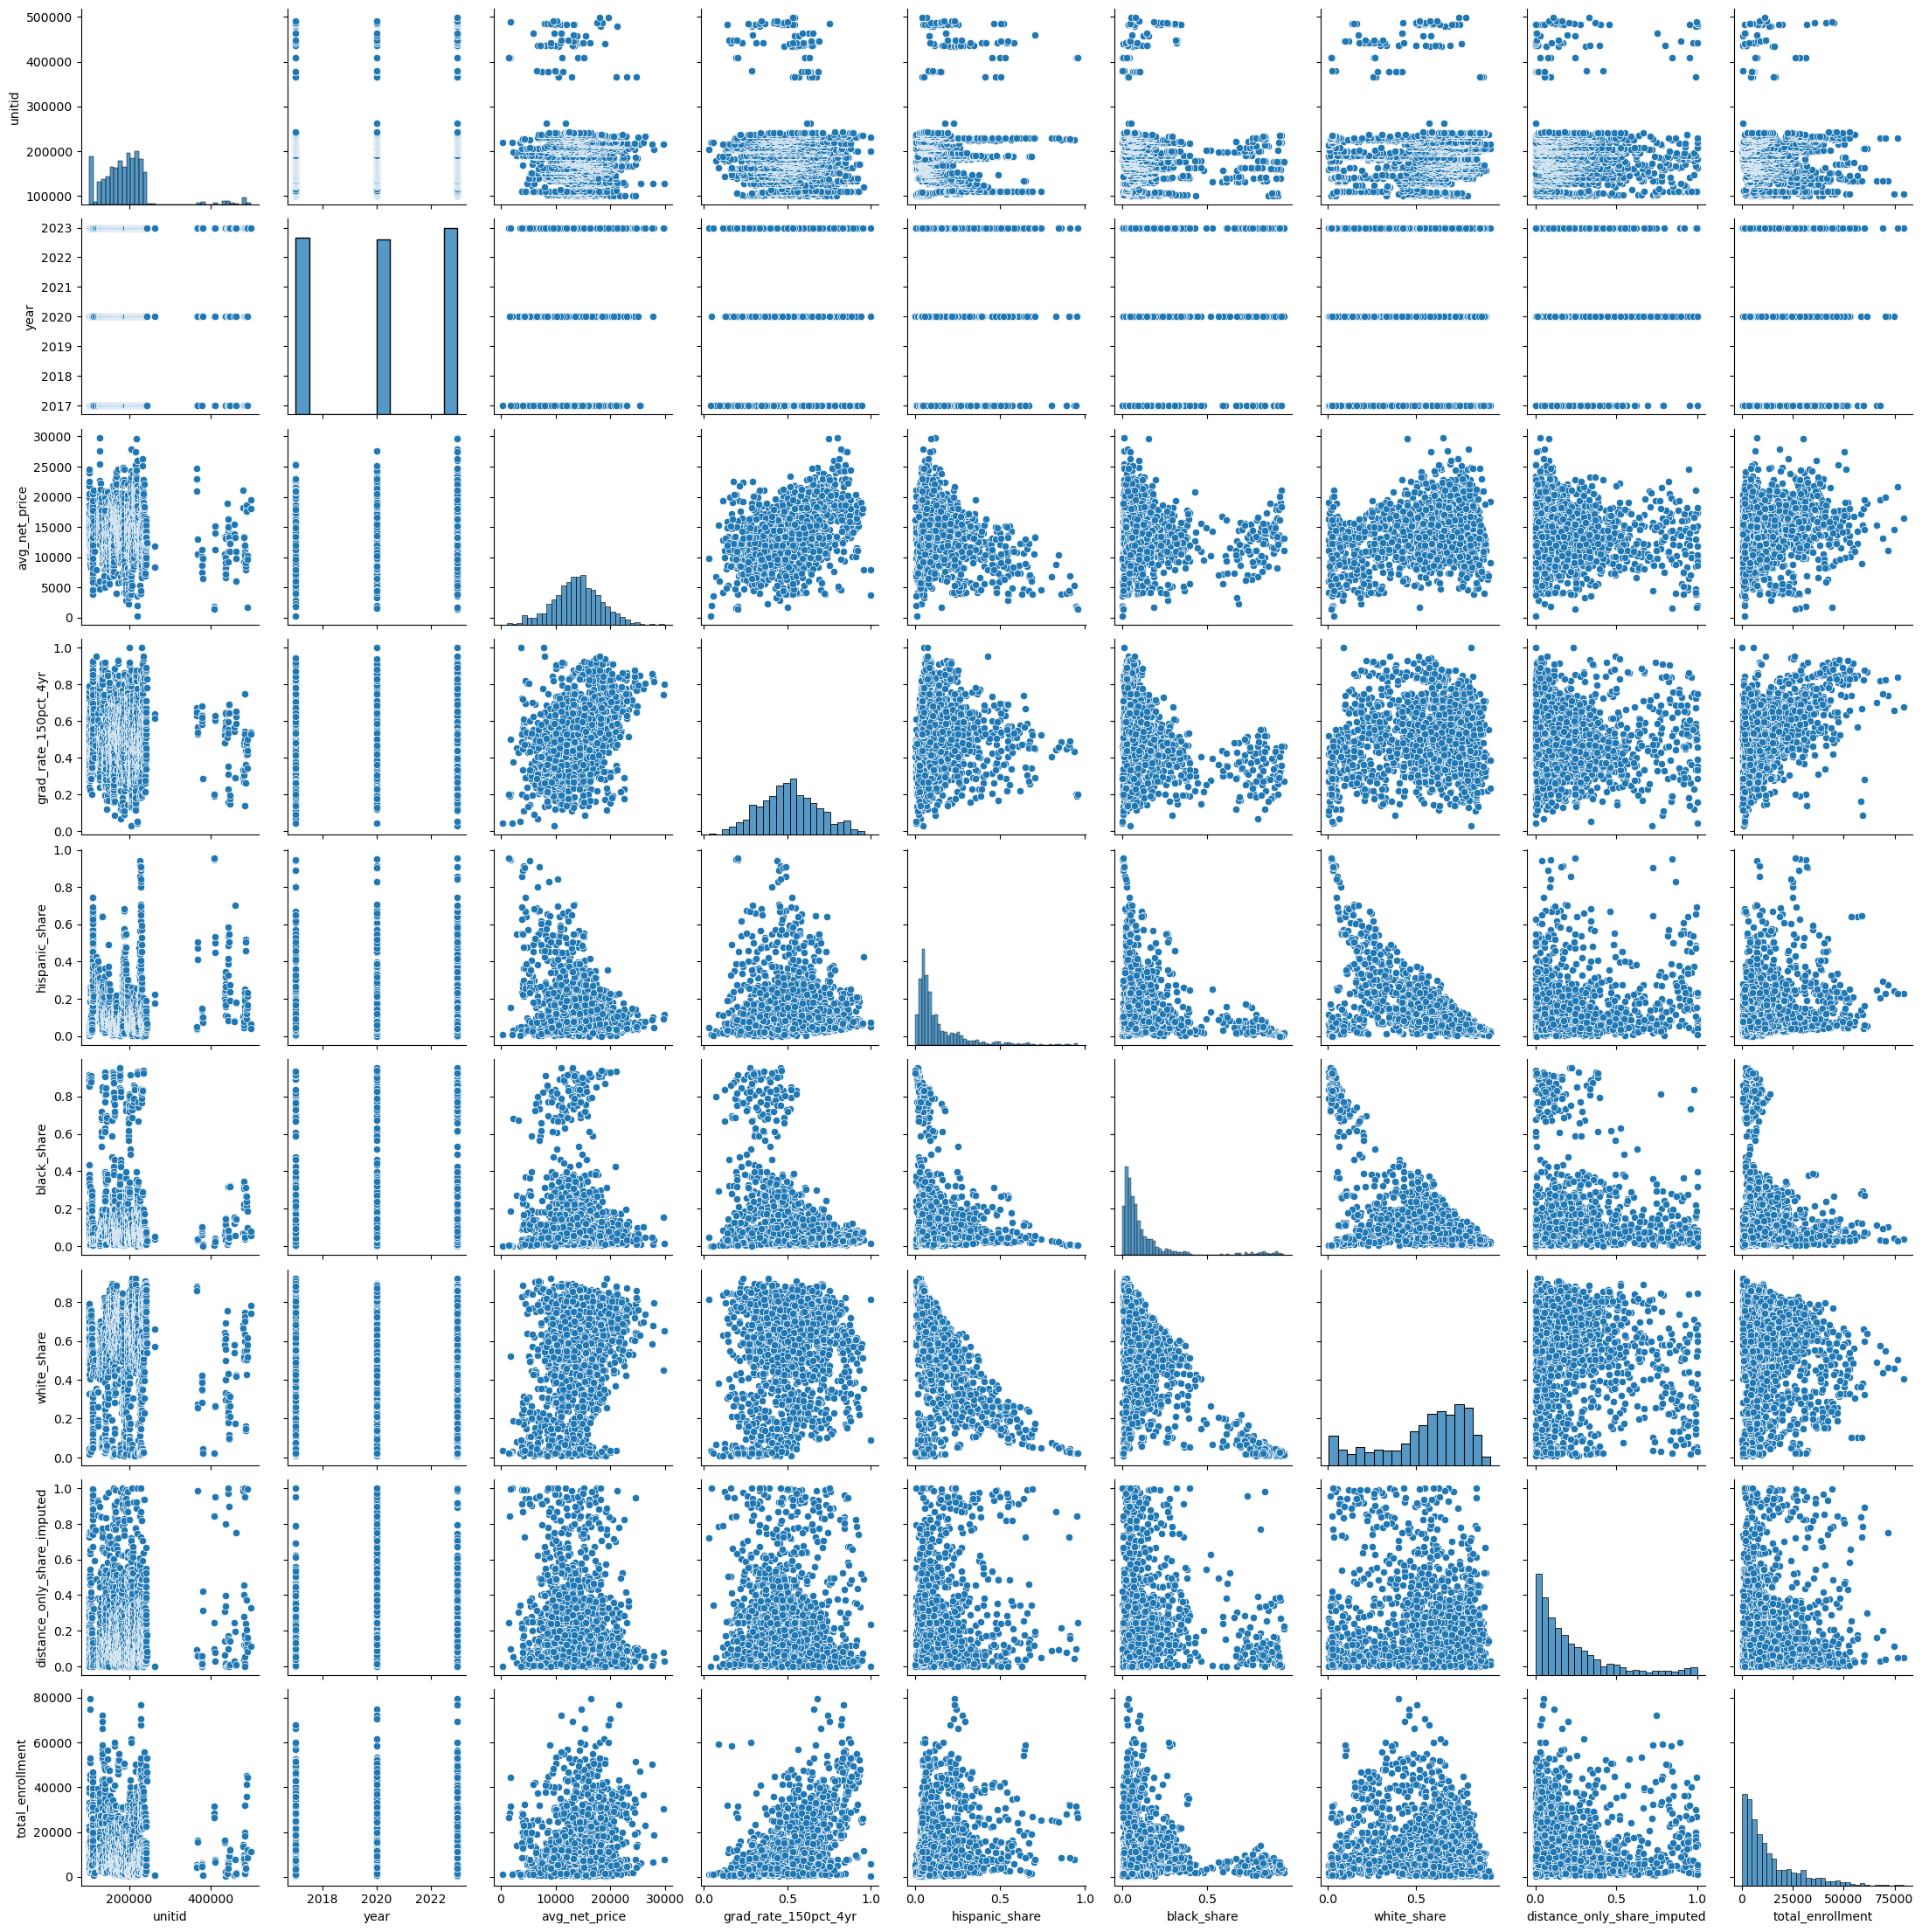

In [39]:
# Pairplot to visualize the relationships between features
sns.pairplot(data = df)

<Axes: >

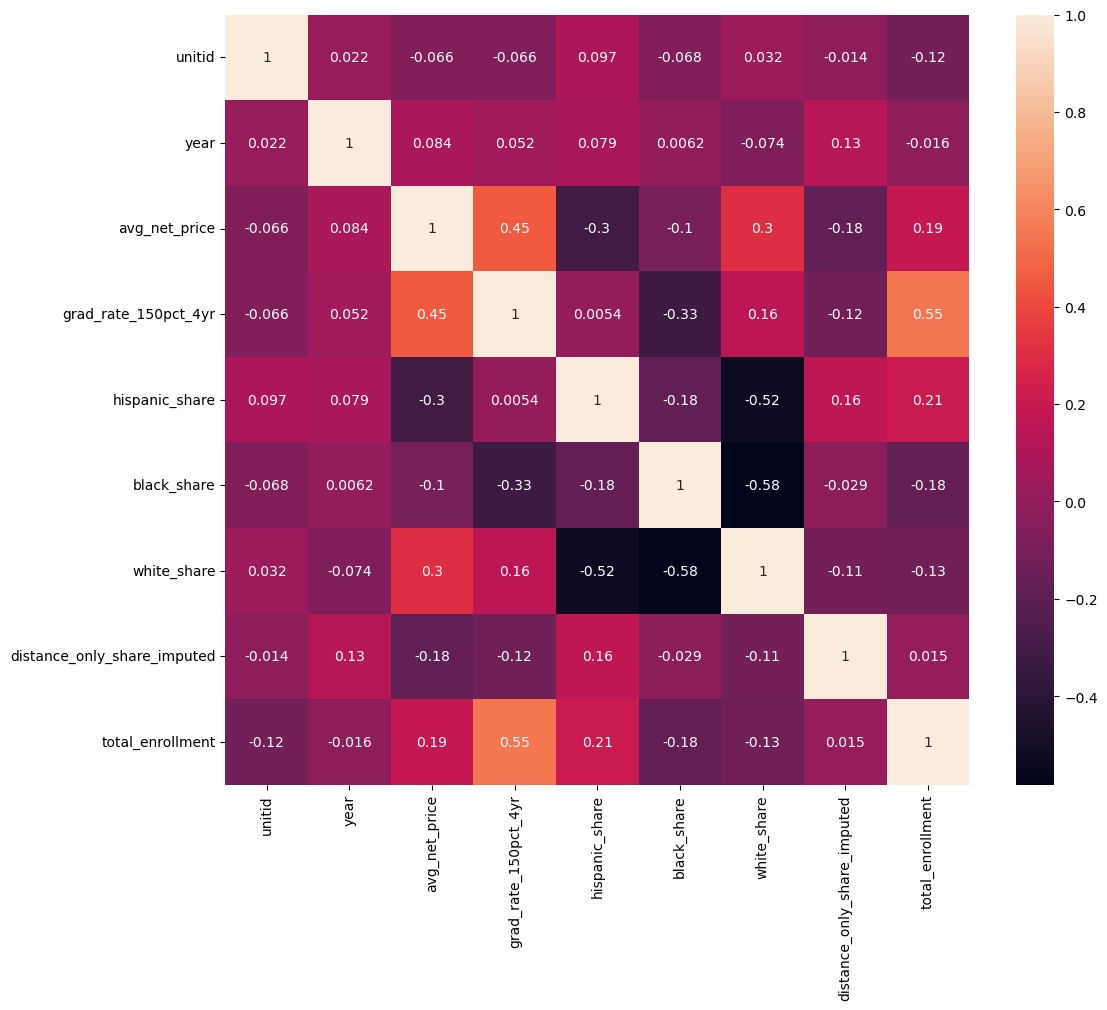

In [41]:
# Correlation matrix to visualize the relationships between features
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=["number"]).corr(), annot=True)

# Model Experiments

In [ ]:
# Remove identifing columns for modeling purposes
model_df = df.drop(columns=["institution_name", "unitid"])

### Model 1

### Model 1 Evaluation

### Model 2

### Model 2 Evaluation

### Model 3

### Model 3 Evauation

# References & AI Transparency
Portions of code were copied (and then edited) from previous in-class studio notes/assignments. Additionally, GitHub Copilot was occasionally used to write code with its Inline Suggestions feature.

Data source: 